      E-COMMERCE SALES ANALYSIS

Dataset Loaded Successfully!

Dataset Shape: (100, 7)

Columns: ['Date', 'Product', 'Quantity', 'Price', 'Customer_ID', 'Region', 'Total_Sales']

Missing Values:
 Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64

Data Cleaning Completed!

           SALES REPORT
Total Sales : ₹12,365,048.00
Average Sales: ₹123,650.48
Best Product : Laptop


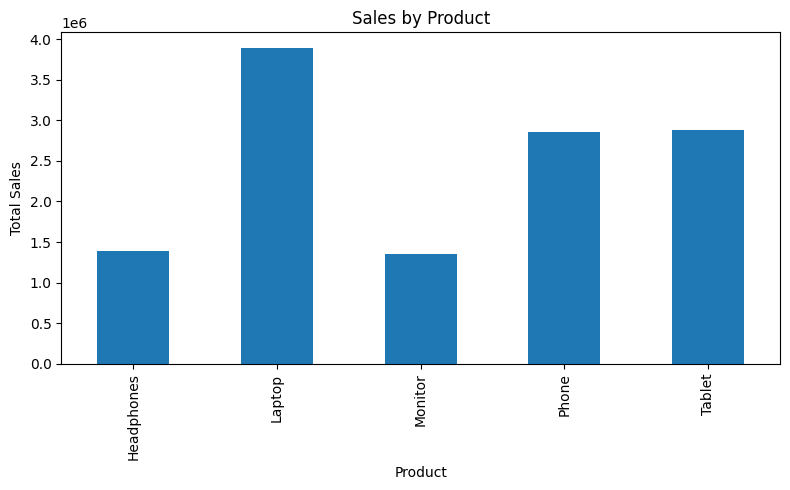

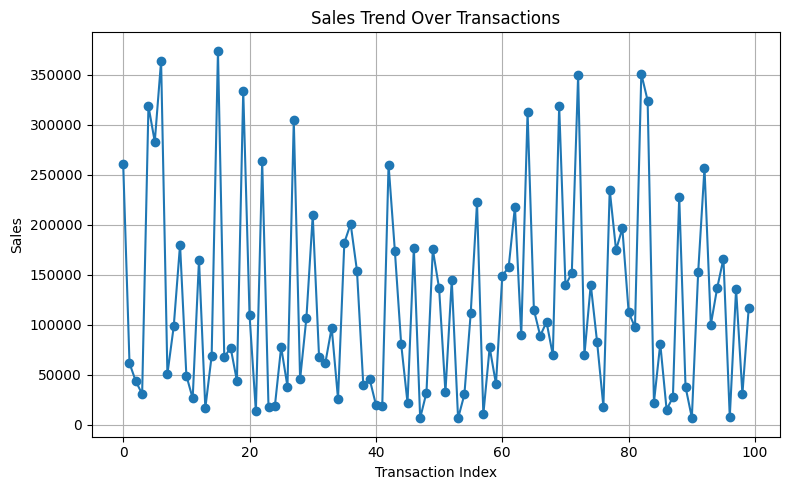

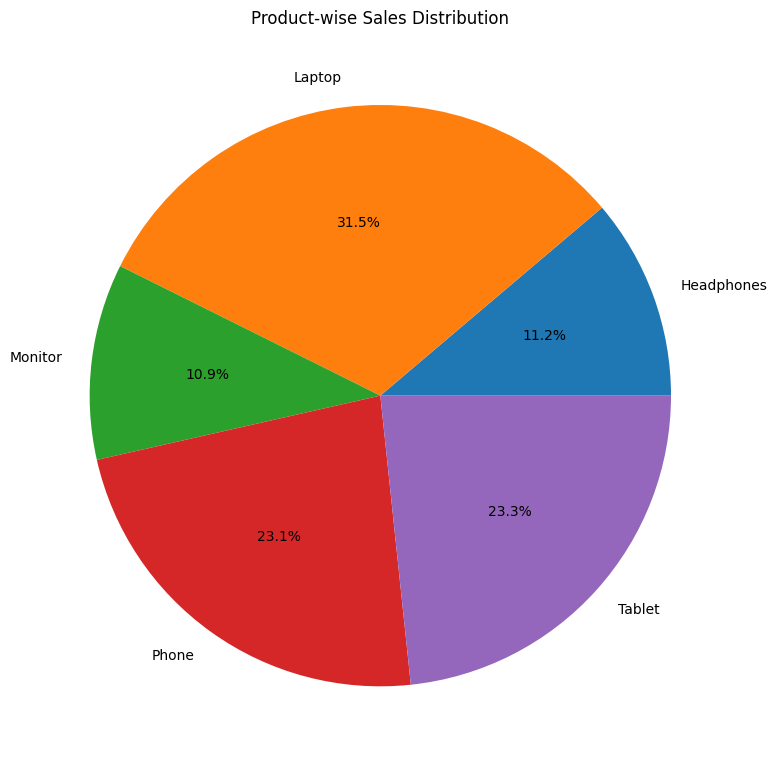


              INSIGHTS
1. Bar chart compares product performance.
2. Line chart shows sales fluctuations over time.
3. Pie chart shows contribution of each product.
4. Best selling product: Laptop

PROJECT COMPLETED SUCCESSFULLY!


In [10]:


import pandas as pd
import matplotlib.pyplot as plt
import os

try:

    print("=" * 50)
    print("      E-COMMERCE SALES ANALYSIS")
    print("=" * 50)


    df = pd.read_csv("/content/sales_data.csv")

    print("\nDataset Loaded Successfully!")

    print("\nDataset Shape:", df.shape)
    print("\nColumns:", df.columns.tolist())
    print("\nMissing Values:\n", df.isnull().sum())



    df.fillna(0, inplace=True)
    df.drop_duplicates(inplace=True)

    print("\nData Cleaning Completed!")


    required_columns = ["Product", "Total_Sales"]

    for col in required_columns:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' not found in dataset")


    total_sales = df["Total_Sales"].sum()
    avg_sales = df["Total_Sales"].mean()

    product_sales = df.groupby("Product")["Total_Sales"].sum()

    best_product = product_sales.idxmax()

    sales_trend = df["Total_Sales"].reset_index()


    print("\n" + "=" * 50)
    print("           SALES REPORT")
    print("=" * 50)

    print(f"Total Sales : ₹{total_sales:,.2f}")
    print(f"Average Sales: ₹{avg_sales:,.2f}")
    print(f"Best Product : {best_product}")

    os.makedirs("visualizations", exist_ok=True)


    plt.figure(figsize=(8,5))
    product_sales.plot(kind="bar")

    plt.title("Sales by Product")
    plt.xlabel("Product")
    plt.ylabel("Total Sales")

    plt.tight_layout()
    plt.savefig("visualizations/bar_sales_by_product.png")
    plt.show()
    plt.close()


    plt.figure(figsize=(8,5))
    plt.plot(sales_trend.index, sales_trend["Total_Sales"], marker="o")

    plt.title("Sales Trend Over Transactions")
    plt.xlabel("Transaction Index")
    plt.ylabel("Sales")

    plt.grid(True)
    plt.tight_layout()
    plt.savefig("visualizations/line_sales_trend.png")
    plt.show()
    plt.close()

    plt.figure(figsize=(8,8))
    product_sales.plot(kind="pie", autopct="%1.1f%%")

    plt.title("Product-wise Sales Distribution")
    plt.ylabel("")

    plt.tight_layout()
    plt.savefig("visualizations/pie_sales_distribution.png")
    plt.show()
    plt.close()



    print("\n" + "=" * 50)
    print("              INSIGHTS")
    print("=" * 50)

    print("1. Bar chart compares product performance.")
    print("2. Line chart shows sales fluctuations over time.")
    print("3. Pie chart shows contribution of each product.")
    print("4. Best selling product:", best_product)

    print("\nPROJECT COMPLETED SUCCESSFULLY!")

except FileNotFoundError:
    print("ERROR: sales_data.csv not found")

except KeyError as e:
    print("ERROR:", e)

except Exception as e:
    print("Unexpected Error:", e)